<a href="https://www.kaggle.com/code/sonawanelalitsunil/weather-data-overview-ml-44-67?scriptVersionId=254587721" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/weather-data/Project 1 - Weather Dataset.csv


##  Title:
Weather Data Overview

## Description:
This dataset contains comprehensive weather-related information, which may include variables such as temperature, humidity, wind speed, precipitation, atmospheric pressure, and weather conditions over time. It is useful for analyzing weather patterns, forecasting trends, evaluating climate changes, and supporting applications in agriculture, transportation, and energy sectors. By using this data, one can build predictive models, visualize seasonal changes, or study the impact of weather on different industries.

## impot dataset


In [2]:
df = pd.read_csv('/kaggle/input/weather-data/Project 1 - Weather Dataset.csv')

In [3]:
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [4]:
df.tail()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow
8783,12/31/2012 23:00,0.0,-2.1,86,30,11.3,99.89,Snow


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [6]:
df.dtypes

Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object

In [7]:
df.shape

(8784, 8)

In [8]:
df.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

## Data visualizations

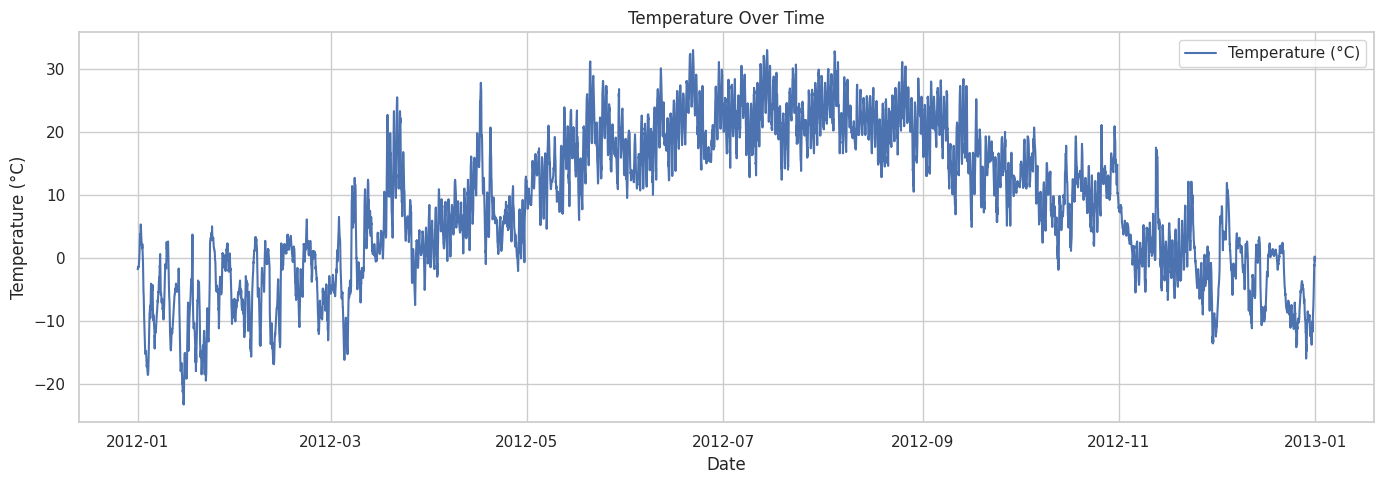

In [11]:
# Convert 'Date/Time' to datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Set the style
sns.set(style="whitegrid")

# 1. Temperature over Time
plt.figure(figsize=(14, 5))
plt.plot(df['Date/Time'], df['Temp_C'], label='Temperature (°C)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.legend()
plt.tight_layout()
plt.show()


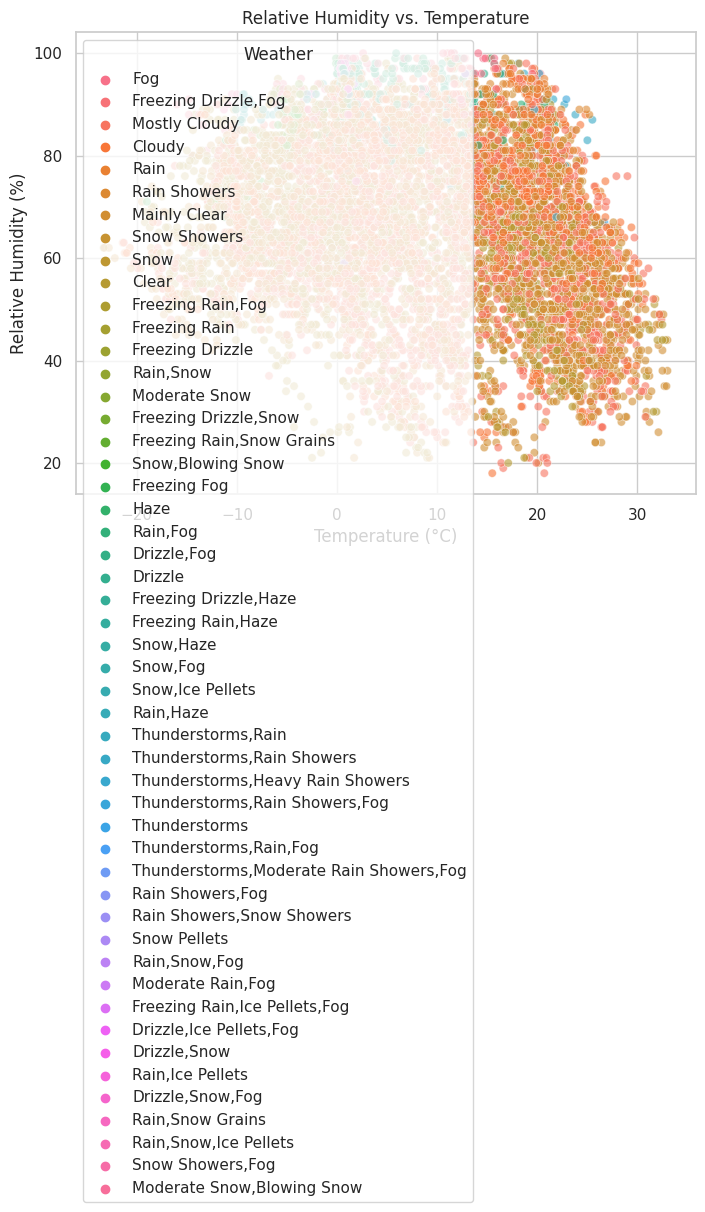

In [12]:
# 2. Relative Humidity vs. Temperature
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Temp_C', y='Rel Hum_%', hue='Weather', alpha=0.6)
plt.title('Relative Humidity vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.tight_layout()
plt.show()

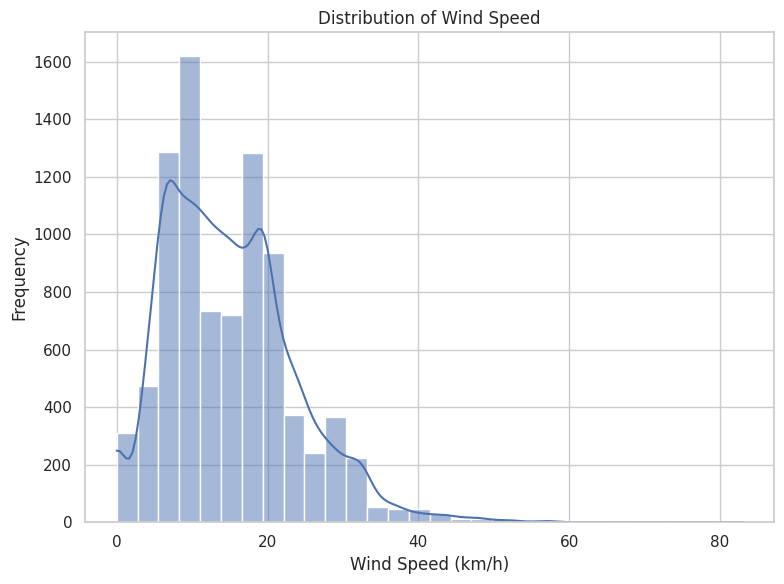

In [13]:
# 3. Wind Speed Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Wind Speed_km/h'], bins=30, kde=True)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

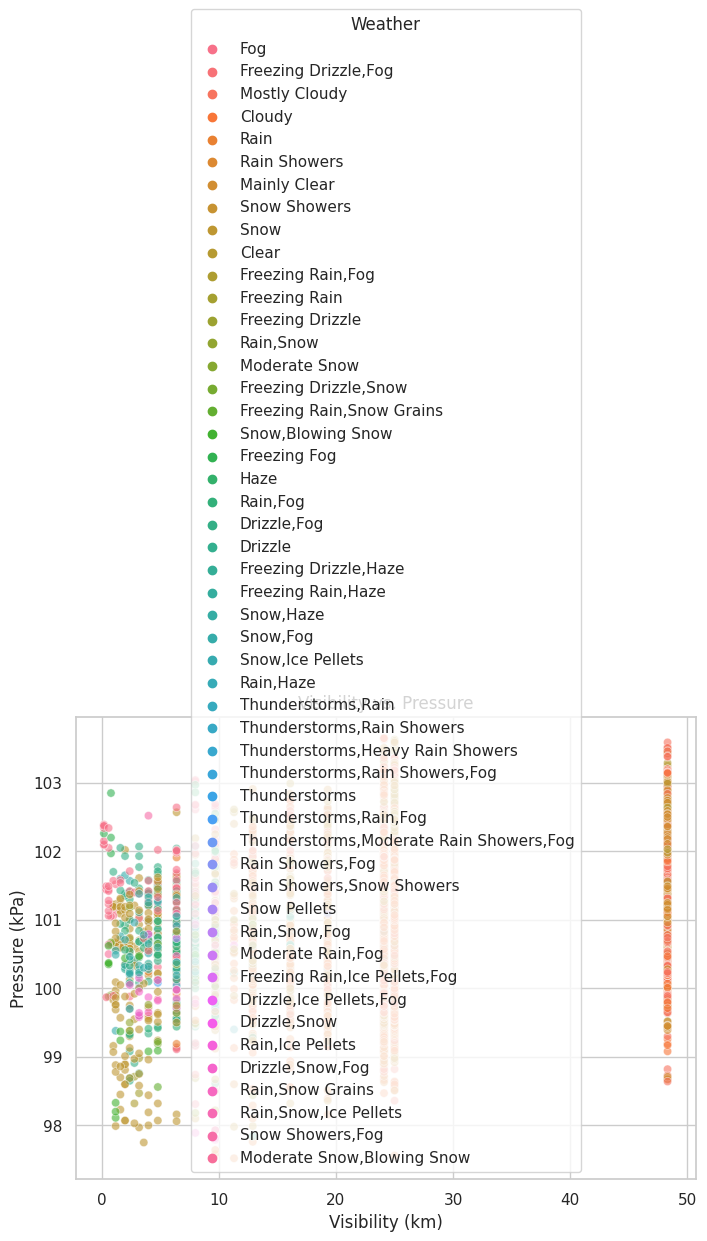

In [14]:
# 4. Visibility vs. Pressure
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Visibility_km', y='Press_kPa', data=df, hue='Weather', alpha=0.6)
plt.title('Visibility vs. Pressure')
plt.xlabel('Visibility (km)')
plt.ylabel('Pressure (kPa)')
plt.tight_layout()
plt.show()


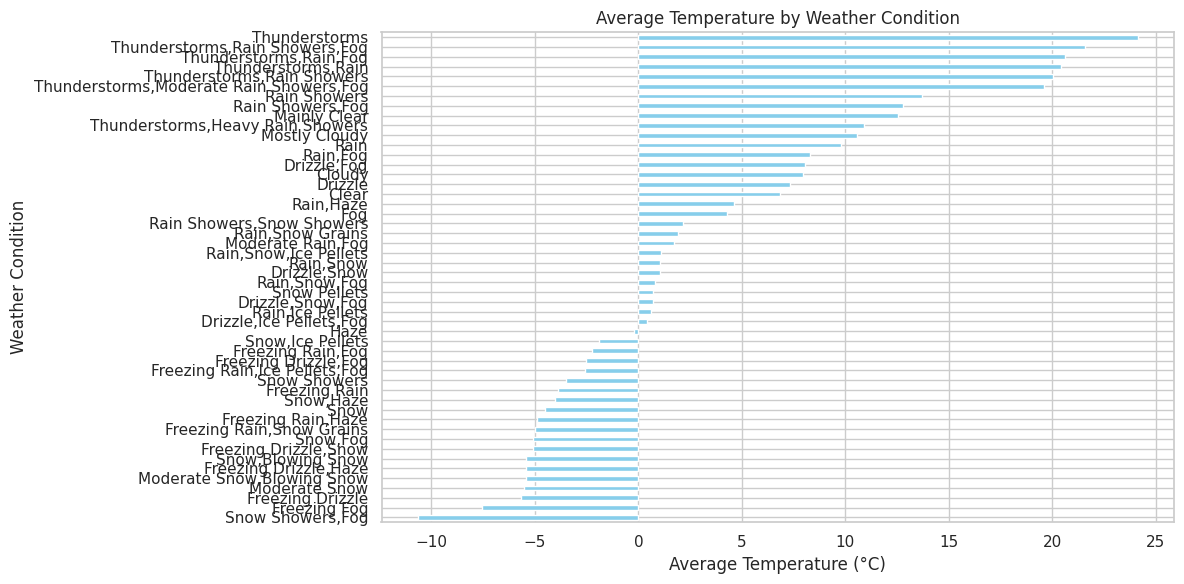

In [15]:
# 5. Average Temperature by Weather Condition
plt.figure(figsize=(12, 6))
avg_temp_by_weather = df.groupby('Weather')['Temp_C'].mean().sort_values()
avg_temp_by_weather.plot(kind='barh', color='skyblue')
plt.title('Average Temperature by Weather Condition')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()

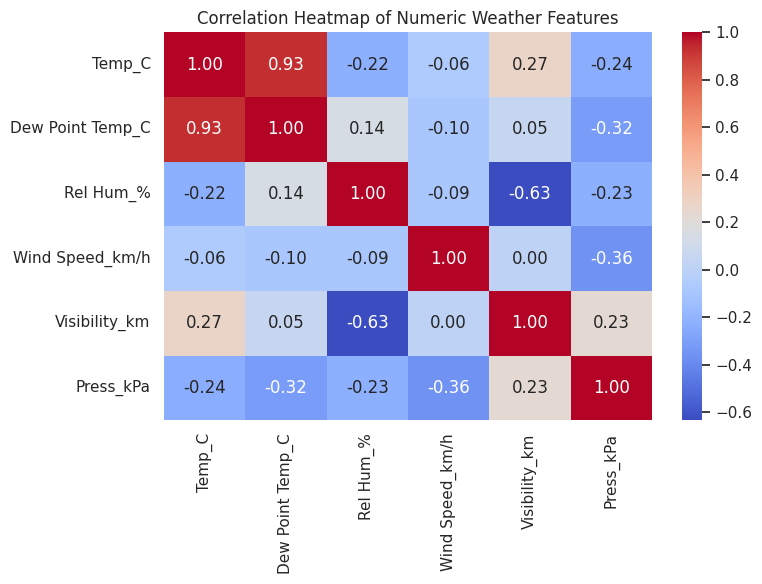

In [16]:
# 6. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Weather Features')
plt.tight_layout()
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# Convert 'Date/Time' to datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Drop the Date/Time column before modeling
df = df.drop(columns=['Date/Time'])

# Encode the target 'Weather'
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])

# Remove classes with only 1 record (for stratified splitting)
class_counts = df['Weather'].value_counts()
valid_classes = class_counts[class_counts > 1].index
df = df[df['Weather'].isin(valid_classes)]

# Separate features and target
X = df.drop('Weather', axis=1)
y = df['Weather']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data (now safe to use stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = acc

# Display results
print("Model Accuracies (%):")
for model, acc in accuracy_results.items():
    print(f"{model}: {acc:.2f}%")

Model Accuracies (%):
Logistic Regression: 36.07%
Decision Tree: 43.48%
Random Forest: 52.48%
Naive Bayes: 32.19%
Support Vector Machine: 39.43%
K-Nearest Neighbors: 44.67%


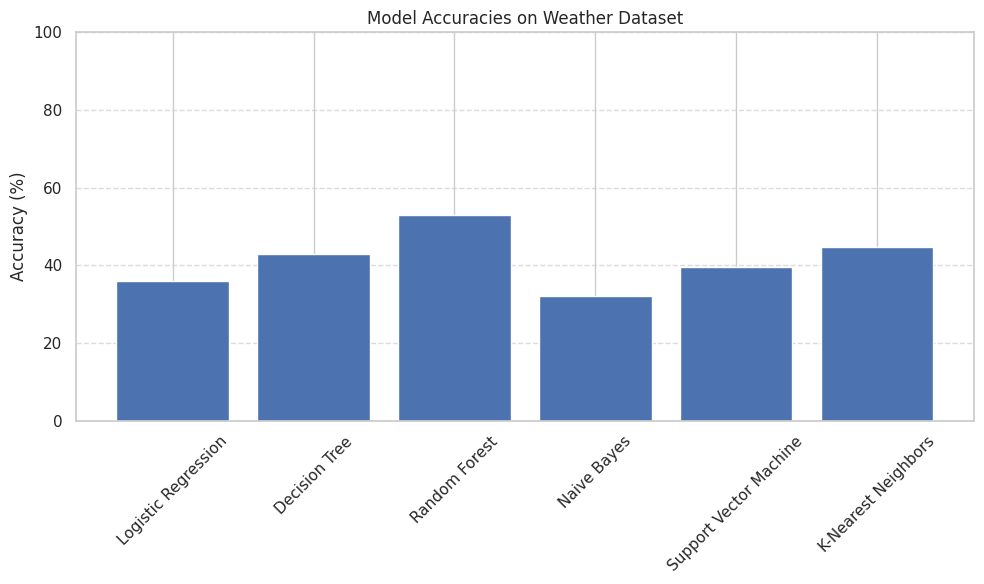

In [20]:
# Accuracy results
accuracy_results = {
    'Logistic Regression': 36.07,
    'Decision Tree': 42.79,
    'Random Forest': 52.88,
    'Naive Bayes': 32.19,
    'Support Vector Machine': 39.43,
    'K-Nearest Neighbors': 44.67
}

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.title('Model Accuracies on Weather Dataset')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Thank you...pls upvote!!!